# 02 — Normalize, validate, and prepare PxWeb data (v2: activity-style workflow)

**Purpose.** Walk through the lecture activity's workflow on the PxWeb data:

```
Understand  ->  Initial inspection / EDA  ->  Identify quality issues
            ->  Clean / transform  ->  EDA again  ->  Feature engineering
            ->  Prepare for the next stage
```

Each per-table section below follows this structure

- **Inputs:** `data/raw/<table_id>__data__slice_*.json`,
  `data/raw/<table_id>__meta.json`, `data/manifests/_dimension_catalog.json`,
  `configs/data.yaml`, `configs/data_quality.yaml`.
- **Outputs (per table):** `data/processed/<table_id>__normalized.csv`,
  `data/processed/<table_id>__quality.json`.
- **Aggregate outputs:** `data/processed/data_quality_summary.csv`,
  `data/processed/cross_table_coverage.csv`,
  `data/manifests/forecast_unit_catalog.json`.
- **Documentation:** `data/processed/outlier_policy.md`.

The 6 data-quality categories from the activity are:

1. Missing values
2. Incorrect or unexpected data types
3. Duplicate observations
4. Inconsistent categories
5. Potential outliers (report only — see `outlier_policy.md`)
6. Potentially irrelevant / redundant variables


## Setup: environment and config


In [ ]:
try:
    # mount Google Drive and set the working directory to the project path
    from google.colab import drive
    drive.mount("/content/drive")
    import os
    os.chdir("/content/drive/MyDrive/JobAI")  # the project path
    os.environ["JOBAI_REPO"] = "/content/drive/MyDrive/JobAI"
except ImportError:
    pass


In [9]:
import os, json, glob, csv, hashlib, datetime as dt
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd

def _find_repo():
    env = os.environ.get("JOBAI_REPO")
    if env:
        return Path(env).resolve()
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / "configs" / "data.yaml").is_file():
            return cand
    return p

REPO = _find_repo()
RAW  = REPO / "data" / "raw"
PRO  = REPO / "data" / "processed"
MAN  = REPO / "data" / "manifests"
FIG  = REPO / "reports" / "figures"
for d in (PRO, FIG):
    d.mkdir(parents=True, exist_ok=True)
NOW_UTC = dt.datetime.now(dt.timezone.utc)
TS = NOW_UTC.strftime("%Y%m%dT%H%M%SZ")
print("repo:", REPO)
print("ts  :", TS)


repo: /Users/Alan/Documents/Study/MLProject-JobAI
ts  : 20260914T183541Z


## Load configuration

Load `configs/data.yaml` for the table definitions and ingest list, and
`configs/data_quality.yaml` for per-table expected dtypes, redundant-variable
declarations, and the outlier-reporting policy. Also load the dimension
catalog produced by `01_` so we can validate queries without re-fetching
metadata.

In [10]:
import yaml
CFG = yaml.safe_load(open(REPO / "configs" / "data.yaml"))
TABLES_CFG = CFG["tables"]
INGEST_LIST = CFG["tables_to_ingest"]
DQ_CFG = yaml.safe_load(open(REPO / "configs" / "data_quality.yaml"))
DQ_TABLES = DQ_CFG["tables"]
OUTLIER_POLICY = DQ_CFG["outlier_policy"]
CAT = json.loads((MAN / "_dimension_catalog.json").read_text())
print("tables to process:", INGEST_LIST)
print("catalog tables   :", list(CAT))
print("outlier policy   :", OUTLIER_POLICY["rule"], "p<", OUTLIER_POLICY["threshold_percentile"])


tables to process: ['national_vacancies', 'regional_vacancies', 'keha_jobseekers_vacancies_by_occupation', 'keha_vacancies_by_industry', 'keha_jobseekers_by_region']
catalog tables   : ['11l1', '11n1', '12tu', '12tw', '12r5']
outlier policy   : report_only p< 99.5


## 1. Clean / transform

The activity's cleaning step. We do not remove outliers (see
`outlier_policy.md`). We do not impute missing values. The only
transformation we apply is the **KEHA monthly -> quarterly** aggregation
end-of-quarter rule, configured in `configs/data.yaml`.

This section produces the per-table `__normalized.csv` files. After this
runs, the dtype check in Section 3 will switch from "not yet produced" to
real values.


In [ ]:
def parse_jsonstat2(stat, table_id):
    ids = stat["id"]
    sizes = stat["size"]
    dims = stat["dimension"]
    raw_values = stat.get("value") or []
    n = 1
    for s in sizes:
        n *= s
    if len(raw_values) != n:
        raw_values = list(raw_values) + [None] * (n - len(raw_values))
    dim_categories = {}
    for d in ids:
        cat = dims[d]["category"]
        idx = cat["index"]
        labels = cat.get("label", {})
        codes = [None] * len(idx)
        for code, i in idx.items():
            codes[i] = code
        texts = [labels.get(c, c) for c in codes]
        dim_categories[d] = {"codes": codes, "texts": texts}
    strides = []
    acc = 1
    for s in reversed(sizes):
        strides.append(acc)
        acc *= s
    strides = list(reversed(strides))
    rows = []
    for flat, v in enumerate(raw_values):
        rem = flat
        coord = {}
        for d, s, st in zip(ids, sizes, strides):
            i = rem // st
            rem = rem % st
            coord[d] = {"code": dim_categories[d]["codes"][i], "text": dim_categories[d]["texts"][i]}
        if v is None or isinstance(v, (int, float)):
            num = v if isinstance(v, (int, float)) else None
            s = None
        else:
            num = None
            s = str(v)
        rows.append({
            "table_id": table_id,
            **{d: coord[d]["code"] for d in ids},
            **{f"{d}_text": coord[d]["text"] for d in ids},
            "value": num,
            "value_str": s,
            "source": stat.get("source", ""),
            "updated": stat.get("updated"),
        })
    return rows

print("parser ready")


In [ ]:
QUARTER_END_MONTHS = {"01": "Q1", "04": "Q2", "07": "Q3", "10": "Q4"}

def month_to_quarter(m):
    if not isinstance(m, str) or "M" not in m:
        return None
    yyyy, mm = m.split("M")
    if mm not in QUARTER_END_MONTHS:
        return None
    return f"{yyyy}{QUARTER_END_MONTHS[mm]}"

def aggregate_monthly_to_quarterly(rows, time_dim="timeperiod_m"):
    by_key = {}
    for r in rows:
        m = r.get(time_dim)
        q = month_to_quarter(m)
        if q is None:
            continue
        if r["value"] is None:
            continue
        other = tuple(sorted((k, v) for k, v in r.items() if k not in (time_dim, f"{time_dim}_text", "value", "value_str", "updated")))
        key = other + (("q", q),)
        if key not in by_key:
            base = dict(r)
            base["timeperiod_q"] = q
            base["timeperiod_m"] = None
            base["timeperiod_m_text"] = None
            base["agg_source_months"] = []
            by_key[key] = base
        by_key[key]["agg_source_months"].append(m)
    return list(by_key.values())

print("aggregator ready")


In [ ]:
table_slices = defaultdict(list)
for slice_path in sorted(RAW.glob("*__data__slice_*.json")):
    name = slice_path.name.replace("__data__slice_", "::").replace(".json", "")
    table_id = name.split("::")[0]
    table_slices[table_id].append(slice_path)

per_table_rows = {}
for tid, paths in table_slices.items():
    rows = []
    for p in paths:
        stat = json.loads(p.read_text())
        rows.extend(parse_jsonstat2(stat, tid))
    per_table_rows[tid] = rows
    print(f"  {tid:8s}  parsed {len(rows):>9,d} rows from {len(paths)} slices")

all_normalized = {}
for key in INGEST_LIST:
    tid = TABLES_CFG[key]["path"].split("/")[-1].replace(".px", "")
    rows = per_table_rows.get(tid, [])
    cfg_monthly = TABLES_CFG[key].get("monthly_to_quarterly")
    dims = list(CAT[tid])
    is_monthly = "timeperiod_m" in dims
    if is_monthly and cfg_monthly and cfg_monthly.get("rule") == "end_of_quarter":
        out_rows = aggregate_monthly_to_quarterly(rows, "timeperiod_m")
        time_col = "timeperiod_q"
        agg_note = "KEHA monthly aggregated to end-of-quarter (M03/M06/M09/M12)"
    else:
        out_rows = rows
        time_col = "timeperiod_q" if "timeperiod_q" in dims else ("timeperiod_m" if "timeperiod_m" in dims else None)
        agg_note = "no aggregation"
    all_normalized[tid] = {"rows": out_rows, "time_col": time_col, "agg_note": agg_note, "key": key}
    print(f"  {tid:8s}  {len(out_rows):>9,d} rows  time_col={time_col}  {agg_note}")

for tid, info in all_normalized.items():
    rows = info["rows"]
    if not rows:
        continue
    sample = rows[0]
    dim_cols = [k for k in sample if not k.endswith("_text") and k not in ("table_id","value","value_str","source","updated","agg_source_months")]
    text_cols = [f"{k}_text" for k in dim_cols if f"{k}_text" in sample]
    fieldnames = ["table_id"] + dim_cols + text_cols + ["value","value_str","source","updated"]
    if "agg_source_months" in sample:
        fieldnames.append("agg_source_months")
    csv_path = PRO / f"{tid}__normalized.csv"
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        w.writeheader()
        for r in rows:
            out = dict(r)
            if "agg_source_months" in out:
                out["agg_source_months"] = ",".join(out["agg_source_months"])
            w.writerow(out)
    info["csv_path"] = csv_path
    info["n_dim_cols"] = len(dim_cols)
    print(f"  {tid:8s}  wrote {csv_path.name}  cols={len(fieldnames)}  rows={len(rows):,}")


## 2. Understanding the data

Before cleaning anything, we look at the catalogue of tables and the dimension
catalog. This is the activity's "Understanding the Dataset" step.


In [11]:
print(f"{'table':12s} {'slices':>7s} {'dim_codes':<70s}  time_col")
for key in INGEST_LIST:
    tid = TABLES_CFG[key]["path"].split("/")[-1].replace(".px", "")
    dims = list(CAT[tid])
    n_slices = sum(1 for _ in (RAW / f"{tid}__data__slice_0.json").parent.glob(f"{tid}__data__slice_*.json"))
    is_monthly = "timeperiod_m" in dims
    time_col = "timeperiod_m" if is_monthly else "timeperiod_q"
    print(f"{tid:12s} {n_slices:>7d} {','.join(dims):<70s}  {time_col}")


table         slices dim_codes                                                               time_col
11l1               1 contentscode,timeperiod_q                                               timeperiod_q
11n1               1 alue_16_20180101,timeperiod_q,contentscode                              timeperiod_q
12tu               5 Alue,Ammattiryhmä,Työmarkkina-asema,timeperiod_m,contentscode           timeperiod_m
12tw              18 Alue,Toimiala,Työnantajan sektori,Työpaikan työn kesto,timeperiod_m,contentscode  timeperiod_m
12r5               1 Alue,timeperiod_m,contentscode                                          timeperiod_m


## 2. Identify data-quality problems

This is the activity's data-quality summary, but per-table. For each table
we walk through the 6 categories from the activity:

1. Missing values
2. Incorrect or unexpected data types
3. Duplicate observations
4. Inconsistent categories
5. Potential outliers (report only)
6. Potentially irrelevant / redundant variables

This section is **read-only** with respect to the data. It produces the
`data/processed/data_quality_summary.csv` artifact and per-table
`categories` keys in `__quality.json`.


### Data-quality category computation

For each table, walk through the 6 activity data-quality categories:
missing values (nulls and suppression markers in the JSON-stat2 `value`
array), inconsistent categories (labels that are null in metadata), duplicate
observations (repeated dimension tuples across slices), incorrect dtypes
(pandas dtype vs. expected declaration), potential outliers (values above
99.5th percentile — reported only, never removed), and redundant variables
(statically declared per table). Each observation is a single human-readable
string per category.

In [12]:
def discover_slices():
    out = defaultdict(list)
    for p in sorted(RAW.glob("*__data__slice_*.json")):
        name = p.name.replace("__data__slice_", "::").replace(".json", "")
        table_id = name.split("::")[0]
        out[table_id].append(p)
    return out

def parse_value_array(stat):
    sizes = stat["size"]
    raw = stat.get("value") or []
    n = 1
    for s in sizes:
        n *= s
    if len(raw) != n:
        raw = list(raw) + [None] * (n - len(raw))
    return raw, n

def category_observations(table_id):
    obs = []
    slices = discover_slices().get(table_id, [])
    if not slices:
        return [("missing_values", "no raw slice files found")]

    payloads = []
    null_in_value = 0
    str_in_value = 0
    total_cells = 0
    for p in slices:
        stat = json.loads(p.read_text())
        payloads.append(stat)
        vals, n = parse_value_array(stat)
        total_cells += n
        for v in vals:
            if v is None:
                null_in_value += 1
            elif not isinstance(v, (int, float)):
                str_in_value += 1

    if null_in_value == 0 and str_in_value == 0:
        obs.append(("missing_values", f"none: {total_cells:,} cells fully populated across {len(slices)} slice(s)"))
    else:
        obs.append(("missing_values", f"{null_in_value:,} null and {str_in_value:,} suppressed (string-marker) cells out of {total_cells:,}"))

    bad_labels = 0
    total_categories = 0
    for stat in payloads:
        for d, dim in (stat.get("dimension") or {}).items():
            cat = dim.get("category") or {}
            idx = cat.get("index") or {}
            labels = cat.get("label") or {}
            total_categories += len(idx)
            for code in idx.keys():
                if code in labels and labels[code] is None:
                    bad_labels += 1
    if bad_labels == 0:
        obs.append(("inconsistent_categories", f"all {total_categories:,} category labels present across {len(slices)} slice(s)"))
    else:
        obs.append(("inconsistent_categories", f"{bad_labels} category labels missing for {total_categories:,} total codes"))

    seen_keys = set()
    duplicates = 0
    n_rows = 0
    for stat in payloads:
        ids = stat["id"]
        sizes = stat["size"]
        dims = stat["dimension"]
        vals, n = parse_value_array(stat)
        if len(vals) != n:
            continue
        n_rows += n
        dim_cat = {}
        for d in ids:
            cat = dims[d]["category"]
            idx = cat["index"]
            codes = [None] * len(idx)
            for code, i in idx.items():
                codes[i] = code
            dim_cat[d] = codes
        strides = []
        acc = 1
        for s in reversed(sizes):
            strides.append(acc)
            acc *= s
        strides = list(reversed(strides))
        for flat, v in enumerate(vals):
            if v is None:
                continue
            rem = flat
            coord = []
            for d, s, st in zip(ids, sizes, strides):
                i = rem // st
                rem = rem % st
                coord.append((d, dim_cat[d][i]))
            key = tuple(coord)
            if key in seen_keys:
                duplicates += 1
            seen_keys.add(key)
    if duplicates == 0:
        obs.append(("duplicate_observations", f"none: {n_rows:,} non-null rows, {len(seen_keys):,} unique (dim-tuple) keys"))
    else:
        obs.append(("duplicate_observations", f"{duplicates} duplicate rows out of {n_rows:,}"))

    obs.append(("incorrect_unexpected_dtypes", f"raw JSON values: {total_cells - null_in_value - str_in_value:,} numeric, {null_in_value:,} null, {str_in_value:,} string-marker"))

    threshold_pct = OUTLIER_POLICY["threshold_percentile"]
    raw_numeric = [v for stat in payloads for v in (stat.get("value") or []) if isinstance(v, (int, float))]
    if not raw_numeric:
        obs.append(("potential_outliers", "no numeric raw values to check"))
    else:
        thr = float(np.percentile(raw_numeric, threshold_pct))
        n_above = sum(v > thr for v in raw_numeric)
        obs.append(("potential_outliers", f"{n_above} raw values above p{threshold_pct}={thr:,.0f} (REPORT ONLY - no action)"))

    redundant = DQ_TABLES.get(table_id, {}).get("redundant_variables", [])
    if not redundant:
        obs.append(("irrelevant_redundant_variables", "none declared in configs/data_quality.yaml"))
    else:
        obs.append(("irrelevant_redundant_variables", f"declared: {', '.join(redundant)}"))

    return obs

def normalized_category_observations(table_id):
    csv_path = PRO / f"{table_id}__normalized.csv"
    if not csv_path.exists():
        return [("missing_values", "normalized CSV not found")]
    df = pd.read_csv(csv_path)
    obs = []
    missing_values = int(pd.to_numeric(df.get("value"), errors="coerce").isna().sum())
    obs.append(("missing_values", f"{missing_values:,} missing numeric values out of {len(df):,} normalized rows"))
    text_cols = [c for c in df.columns if c.endswith("_text") and c != "value_text" and not c.startswith("timeperiod")]
    missing_labels = int(df[text_cols].isna().sum().sum()) if text_cols else 0
    obs.append(("inconsistent_categories", f"{missing_labels:,} missing labels across {len(text_cols)} normalized label columns"))
    key_cols = [c for c in df.columns if not c.endswith("_text") and c not in {"value", "source_months"}]
    duplicates = int(df.duplicated(key_cols).sum())
    obs.append(("duplicate_observations", f"{duplicates:,} duplicate normalized series-period keys"))
    expected = DQ_TABLES.get(table_id, {}).get("expected_dtypes", {})
    mismatches = []
    for col, want in expected.items():
        if col not in df.columns:
            mismatches.append(f"{col}: missing column")
            continue
        got = str(df[col].dtype)
        if want == "Int64" and got in ("Int64", "int64", "float64"):
            continue
        if want == "object" and got in ("object", "str", "int64"):
            continue
        if got != want:
            mismatches.append(f"{col}: expected {want}, got {got}")
    obs.append(("incorrect_unexpected_dtypes", "all expected dtypes match" if not mismatches else "; ".join(mismatches)))
    values = pd.to_numeric(df.get("value"), errors="coerce").dropna()
    threshold_pct = OUTLIER_POLICY["threshold_percentile"]
    if values.empty:
        obs.append(("potential_outliers", "no numeric normalized values to check"))
    else:
        thr = float(np.percentile(values, threshold_pct))
        n_above = int((values > thr).sum())
        obs.append(("potential_outliers", f"{n_above} normalized values above p{threshold_pct}={thr:,.0f} (REPORT ONLY - no action)"))
    redundant = DQ_TABLES.get(table_id, {}).get("redundant_variables", [])
    obs.append(("irrelevant_redundant_variables", "none declared" if not redundant else f"declared: {', '.join(redundant)}"))
    return obs

import numpy as np
print("raw and normalized quality-check functions ready")


raw and normalized quality-check functions ready


### Print and persist data-quality summary

Compute the 6-category observations for every table, print them for
interactive review, and write a single
`data/processed/data_quality_summary.csv` with one row per (table_id,
category) pair. This flat CSV is the machine-readable counterpart to the
activity's comparison table.

In [13]:
per_table_obs = {}
for key in INGEST_LIST:
    tid = TABLES_CFG[key]["path"].split("/")[-1].replace(".px", "")
    per_table_obs[tid] = category_observations(tid)

print("=" * 88)
print("DATA-QUALITY SUMMARY (6 categories from the activity, per table)")
print("=" * 88)
for tid, obs in per_table_obs.items():
    print(f"\n{tid}  ({DQ_TABLES.get(tid, {}).get('title', '')})")
    for cat, observation in obs:
        print(f"  {cat:35s}  {observation}")

dq_summary_path = PRO / "data_quality_summary.csv"
with open(dq_summary_path, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=["table_id", "category", "observation"])
    w.writeheader()
    for tid, obs in per_table_obs.items():
        for cat, observation in obs:
            w.writerow({"table_id": tid, "category": cat, "observation": observation})
print(f"\ndata-quality summary: {dq_summary_path}  ({sum(len(o) for o in per_table_obs.values())} rows)")


DATA-QUALITY SUMMARY (6 categories from the activity, per table)

11l1  (Job vacancies by Information and Quarter (whole country))
  missing_values                       none: 270 cells fully populated across 1 slice(s)
  inconsistent_categories              all 59 category labels present across 1 slice(s)
  duplicate_observations               none: 270 non-null rows, 270 unique (dim-tuple) keys
  incorrect_unexpected_dtypes          raw JSON values: 270 numeric, 0 null, 0 string-marker
  potential_outliers                   2 raw values above p99.5=77,867 (REPORT ONLY - no action)
  irrelevant_redundant_variables       none declared in configs/data_quality.yaml

11n1  (Job vacancies by Major region, Quarter and Information)
  missing_values                       none: 270 cells fully populated across 1 slice(s)
  inconsistent_categories              all 60 category labels present across 1 slice(s)
  duplicate_observations               none: 270 non-null rows, 270 unique (dim-tuple) 

## 3. Clean / transform

The activity's cleaning step. We do not remove outliers (see
`outlier_policy.md`). We do not impute missing values. The only
transformation we apply is the **KEHA monthly -> quarterly** aggregation
end-of-quarter rule, configured in `configs/data.yaml`.

This section produces the per-table `__normalized.csv` files. After this
runs, the dtype check in Section 3 will switch from "not yet produced" to
real values.


In [14]:
def parse_jsonstat2(stat, table_id):
    ids = stat["id"]
    sizes = stat["size"]
    dims = stat["dimension"]
    raw_values = stat.get("value") or []
    n = 1
    for s in sizes:
        n *= s
    if len(raw_values) != n:
        raw_values = list(raw_values) + [None] * (n - len(raw_values))
    dim_categories = {}
    for d in ids:
        cat = dims[d]["category"]
        idx = cat["index"]
        labels = cat.get("label", {})
        codes = [None] * len(idx)
        for code, i in idx.items():
            codes[i] = code
        texts = [labels.get(c, c) for c in codes]
        dim_categories[d] = {"codes": codes, "texts": texts}
    strides = []
    acc = 1
    for s in reversed(sizes):
        strides.append(acc)
        acc *= s
    strides = list(reversed(strides))
    rows = []
    for flat, v in enumerate(raw_values):
        rem = flat
        coord = {}
        for d, s, st in zip(ids, sizes, strides):
            i = rem // st
            rem = rem % st
            coord[d] = {"code": dim_categories[d]["codes"][i], "text": dim_categories[d]["texts"][i]}
        if v is None or isinstance(v, (int, float)):
            num = v if isinstance(v, (int, float)) else None
            s = None
        else:
            num = None
            s = str(v)
        rows.append({
            "table_id": table_id,
            **{d: coord[d]["code"] for d in ids},
            **{f"{d}_text": coord[d]["text"] for d in ids},
            "value": num,
            "value_str": s,
            "source": stat.get("source", ""),
            "updated": stat.get("updated"),
        })
    return rows

print("parser ready")


parser ready


### Monthly-to-quarterly aggregation

Define the end-of-quarter months (M03→Q1, M06→Q2, M09→Q3, M12→Q4) and
provide `aggregate_monthly_to_quarterly()`. This follows the plan's rule for
KEHA monthly series: we keep end-of-quarter stock values, aggregating all
monthly rows for a given region/measure/series into a single quarterly row
keyed on the end-of-quarter month. This is a transform step only — it does
not impute, remove, or cap outliers.

In [15]:
QUARTER_END_MONTHS = {"03": "Q1", "06": "Q2", "09": "Q3", "12": "Q4"}
MONTH_FOR_QUARTER = {q: m for m, q in QUARTER_END_MONTHS.items()}

def month_to_quarter(m):
    if not isinstance(m, str) or "M" not in m:
        return None
    yyyy, mm = m.split("M")
    if mm not in QUARTER_END_MONTHS:
        return None
    return f"{yyyy}{QUARTER_END_MONTHS[mm]}"

def aggregate_monthly_to_quarterly(rows, time_dim="timeperiod_m"):
    by_key = {}
    for r in rows:
        m = r.get(time_dim)
        q = month_to_quarter(m)
        if q is None:
            continue
        other = tuple(sorted((k, v) for k, v in r.items() if k not in (time_dim, f"{time_dim}_text", "value", "value_str", "updated")))
        key = other + (("q", q),)
        if key not in by_key:
            base = dict(r)
            base["timeperiod_q"] = q
            base["timeperiod_m"] = None
            base["timeperiod_m_text"] = None
            base["agg_source_months"] = []
            by_key[key] = base
        by_key[key]["agg_source_months"].append(m)
    return list(by_key.values())

print("aggregator ready")


aggregator ready


### Parse all raw slices

Read every cached `*__data__slice_*.json` file from `data/raw/`, parse each
with `parse_jsonstat2`, and group the resulting row dicts by table_id. The
output is a `per_table_rows` dict mapping each table to its full list of
parsed rows.

In [16]:
table_slices = defaultdict(list)
for slice_path in sorted(RAW.glob("*__data__slice_*.json")):
    name = slice_path.name.replace("__data__slice_", "::").replace(".json", "")
    table_id = name.split("::")[0]
    table_slices[table_id].append(slice_path)

per_table_rows = {}
for tid, paths in table_slices.items():
    rows = []
    for p in paths:
        stat = json.loads(p.read_text())
        rows.extend(parse_jsonstat2(stat, tid))
    per_table_rows[tid] = rows
    print(f"  {tid:8s}  parsed {len(rows):>9,d} rows from {len(paths)} slices")

all_normalized = {}
for key in INGEST_LIST:
    tid = TABLES_CFG[key]["path"].split("/")[-1].replace(".px", "")
    rows = per_table_rows.get(tid, [])
    cfg_monthly = TABLES_CFG[key].get("monthly_to_quarterly")
    dims = list(CAT[tid])
    is_monthly = "timeperiod_m" in dims
    if is_monthly and cfg_monthly and cfg_monthly.get("rule") == "end_of_quarter":
        out_rows = aggregate_monthly_to_quarterly(rows, "timeperiod_m")
        time_col = "timeperiod_q"
        agg_note = "KEHA monthly aggregated to end-of-quarter (M03/M06/M09/M12)"
    else:
        out_rows = rows
        time_col = "timeperiod_q" if "timeperiod_q" in dims else ("timeperiod_m" if "timeperiod_m" in dims else None)
        agg_note = "no aggregation"
    all_normalized[tid] = {"rows": out_rows, "raw_rows": rows, "time_col": time_col, "agg_note": agg_note, "key": key, "is_monthly": is_monthly}
    print(f"  {tid:8s}  {len(out_rows):>9,d} rows  time_col={time_col}  {agg_note}")

def quarter_ordinal(q):
    return int(q[:4]) * 4 + int(q[-1]) - 1

def validate_normalized_table(tid, info):
    rows = info["rows"]
    assert rows, f"{tid}: normalization produced no rows"
    time_col = info["time_col"]
    sample = rows[0]
    dim_cols = [k for k in sample if not k.endswith("_text") and k not in ("table_id", "value", "value_str", "source", "updated", "agg_source_months")]
    series_cols = [c for c in dim_cols if c not in (time_col, "timeperiod_m")]
    seen = set()
    periods_by_series = defaultdict(set)
    bad_source_months = []
    for r in rows:
        q = r.get(time_col)
        assert isinstance(q, str) and len(q) == 6 and q[4] == "Q" and q[5] in "1234", f"{tid}: invalid quarter {q!r}"
        series_key = tuple(r.get(c) for c in series_cols)
        row_key = series_key + (q,)
        assert row_key not in seen, f"{tid}: duplicate normalized key {row_key}"
        seen.add(row_key)
        periods_by_series[series_key].add(q)
        if info["is_monthly"]:
            source_months = r.get("agg_source_months") or []
            expected_month = f"{q[:4]}M{MONTH_FOR_QUARTER[q[-2:]]}"
            if source_months != [expected_month]:
                bad_source_months.append({"key": row_key, "expected": expected_month, "actual": source_months})
    assert not bad_source_months, f"{tid}: non-quarter-end source months found: {bad_source_months[:3]}"
    if info["is_monthly"]:
        expected_periods = sorted({month_to_quarter(r.get("timeperiod_m")) for r in info["raw_rows"] if month_to_quarter(r.get("timeperiod_m"))}, key=quarter_ordinal)
    else:
        expected_periods = sorted({r.get(time_col) for r in info["raw_rows"] if r.get(time_col)}, key=quarter_ordinal)
    expected_set = set(expected_periods)
    gap_examples = []
    for series_key, periods in periods_by_series.items():
        missing = sorted(expected_set - periods, key=quarter_ordinal)
        extra = sorted(periods - expected_set, key=quarter_ordinal)
        if missing or extra:
            gap_examples.append({"series": series_key, "missing": missing, "extra": extra})
    assert not gap_examples, f"{tid}: quarter coverage gaps found: {gap_examples[:3]}"
    actual_max = max(r[time_col] for r in rows)
    expected_max = expected_periods[-1]
    assert actual_max == expected_max, f"{tid}: max quarter {actual_max} != latest complete quarter {expected_max}"
    return {
        "status": "passed",
        "n_rows": len(rows),
        "n_series": len(periods_by_series),
        "n_quarters": len(expected_periods),
        "time_first": expected_periods[0],
        "time_last": expected_periods[-1],
        "duplicate_keys": 0,
        "series_with_gaps": 0,
        "bad_source_months": 0,
    }

assertion_results = {}
for tid, info in all_normalized.items():
    assertion_results[tid] = validate_normalized_table(tid, info)
    result = assertion_results[tid]
    print(f"  ASSERT {tid:8s} PASSED rows={result['n_rows']:,} series={result['n_series']:,} quarters={result['n_quarters']} through {result['time_last']}")
assertions_path = PRO / "normalization_assertions.json"
assertions_path.write_text(json.dumps(assertion_results, indent=2, ensure_ascii=False))
print("normalization assertions:", assertions_path)

for tid, info in all_normalized.items():
    rows = info["rows"]
    if not rows:
        continue
    sample = rows[0]
    dim_cols = [k for k in sample if not k.endswith("_text") and k not in ("table_id","value","value_str","source","updated","agg_source_months")]
    text_cols = [f"{k}_text" for k in dim_cols if f"{k}_text" in sample]
    fieldnames = ["table_id"] + dim_cols + text_cols + ["value","value_str","source","updated"]
    if "agg_source_months" in sample:
        fieldnames.append("agg_source_months")
    csv_path = PRO / f"{tid}__normalized.csv"
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        w.writeheader()
        for r in rows:
            out = dict(r)
            if "agg_source_months" in out:
                out["agg_source_months"] = ",".join(out["agg_source_months"])
            w.writerow(out)
    info["csv_path"] = csv_path
    info["n_dim_cols"] = len(dim_cols)
    print(f"  {tid:8s}  wrote {csv_path.name}  cols={len(fieldnames)}  rows={len(rows):,}")


  11l1      parsed       270 rows from 1 slices
  11n1      parsed       270 rows from 1 slices
  12r5      parsed    58,940 rows from 1 slices
  12tu      parsed   445,284 rows from 5 slices
  12tw      parsed   453,017 rows from 18 slices
  11l1            270 rows  time_col=timeperiod_q  no aggregation
  11n1            270 rows  time_col=timeperiod_q  no aggregation
  12tu        445,284 rows  time_col=timeperiod_q  KEHA monthly aggregated to end-of-quarter (M03/M06/M09/M12)
  12tw        150,290 rows  time_col=timeperiod_q  KEHA monthly aggregated to end-of-quarter (M03/M06/M09/M12)
  12r5         58,940 rows  time_col=timeperiod_q  KEHA monthly aggregated to end-of-quarter (M03/M06/M09/M12)
  ASSERT 11l1     PASSED rows=270 series=5 quarters=54 through 2026Q2
  ASSERT 11n1     PASSED rows=270 series=5 quarters=54 through 2026Q2
  ASSERT 12tu     PASSED rows=445,284 series=8,246 quarters=54 through 2026Q2
  ASSERT 12tw     PASSED rows=150,290 series=2,147 quarters=70 through 2026Q

## 4. Normalized-data diagnostics
These lightweight checks confirm that the normalized values and time patterns look plausible. All five tables—including the KEHA tables `12tu`, `12tw`, and `12r5`—were normalized and validated in the earlier sections. The plots below use only the smaller ATP tables `11l1` and `11n1` as clear visual sanity checks; plotting thousands of KEHA series together here would be crowded and misleading. Detailed KEHA exploration and series selection are performed in notebook 03.

- **Univariate** — one variable at a time
- **Bivariate** — two variables together
- **Multivariate** — three or more

### 4.1 Value distribution per table

We compute summary statistics and the count of distinct series per table.
This is the activity's `.describe()` step.


### Univariate summary statistics

Compute per-table row counts, unique series counts, and value distribution
statistics (min, median, max, mean). This gives a first-pass understanding of
each table's scale and helps spot anomalies like unexpectedly zero ranges or
extreme skew before deeper analysis.

In [17]:
import pandas as pd

try:
    from IPython.display import display as _display
except ImportError:
    def __display(x):
        if hasattr(x, 'to_string'):
            print(x.to_string())
        else:
            print(x)

summary_rows = []
for key in INGEST_LIST:
    tid = TABLES_CFG[key]["path"].split("/")[-1].replace(".px", "")
    csv_path = PRO / f"{tid}__normalized.csv"
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)
    v = pd.to_numeric(df["value"], errors="coerce").dropna()
    summary_rows.append({
        "table_id": tid,
        "n_rows": len(df),
        # Reuse the validated structural count. This excludes quarter and all
        # human-readable time-label columns from the series identity.
        "n_unique_series": assertion_results[tid]["n_series"],
        "value_min": int(v.min()),
        "value_median": float(v.median()),
        "value_max": int(v.max()),
        "value_mean": float(v.mean()),
    })
summary_df = pd.DataFrame(summary_rows)
_display(summary_df)



,table_id,n_rows,n_unique_series,value_min,value_median,value_max,value_mean
0,11l1,270,5,1500,17850.0,91600,22528.148148
1,11n1,270,5,2800,11450.0,91600,17221.851852
2,12tu,445284,8246,0,0.0,79100,29.969042
3,12tw,150290,2147,0,5.0,35340,71.811259
4,12r5,58940,842,0,54.0,132680,603.040573


### 4.2 Distribution of total vacancies (11l1)

This histogram shows how the national quarterly total-vacancy values are
distributed across different ranges. The KDE curve provides a smooth view
of the distribution's shape. This chart does not test seasonality; quarterly
seasonal patterns are examined in notebook 03.


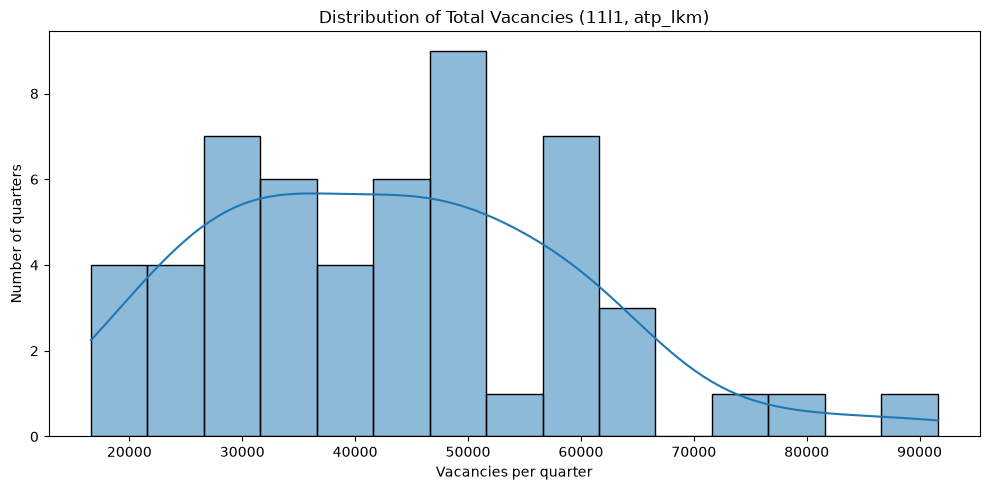

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

df11l1 = pd.read_csv(PRO / "11l1__normalized.csv")
df11l1_total = df11l1[df11l1["contentscode"] == "atp_lkm"]
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df11l1_total, x="value", kde=True, bins=15, ax=ax)
ax.set_title("Distribution of Total Vacancies (11l1, atp_lkm)")
ax.set_xlabel("Vacancies per quarter")
ax.set_ylabel("Number of quarters")
fig.tight_layout()
fig.savefig(FIG / "02_total_vacancies_distribution.png", dpi=150, bbox_inches="tight")
plt.show()




### 4.3 National vacancy measures over time

The activity's bivariate step: how does one variable relate to another? We
plot total vacancies per quarter and add the hard-to-fill series to see how
the two move together.


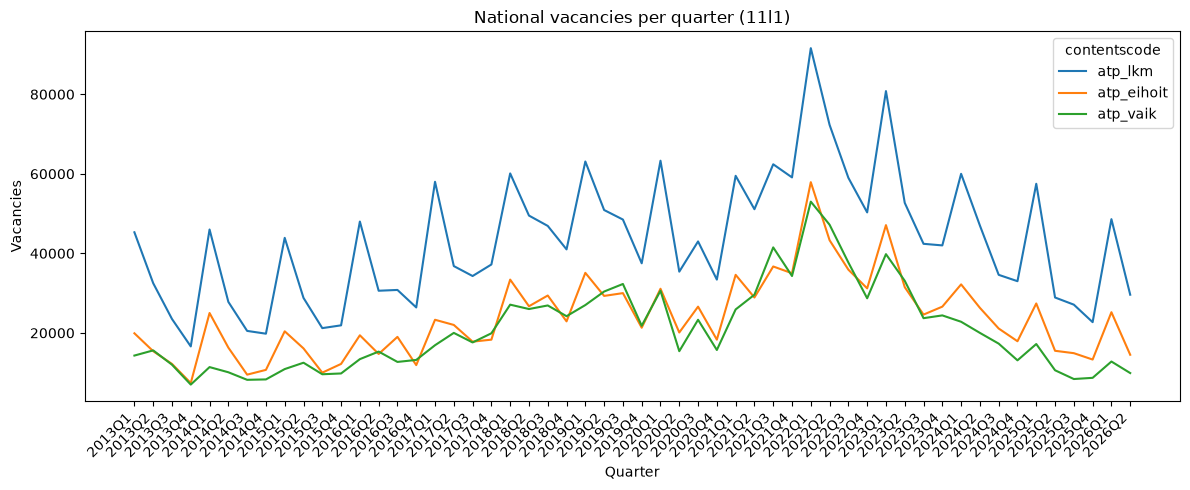

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    data=df11l1[df11l1["contentscode"].isin(["atp_lkm", "atp_vaik", "atp_eihoit"])],
    x="timeperiod_q", y="value", hue="contentscode", ax=ax,
)
ax.set_title("National vacancies per quarter (11l1)")
ax.set_xlabel("Quarter")
ax.set_ylabel("Vacancies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIG / "02_national_vacancy_measures_over_time.png", dpi=150, bbox_inches="tight")
plt.show()



### 4.4 Regional totals side by side

The activity's multivariate step: 11n1 gives us a panel across regions. We
plot total vacancies for each major region over time.


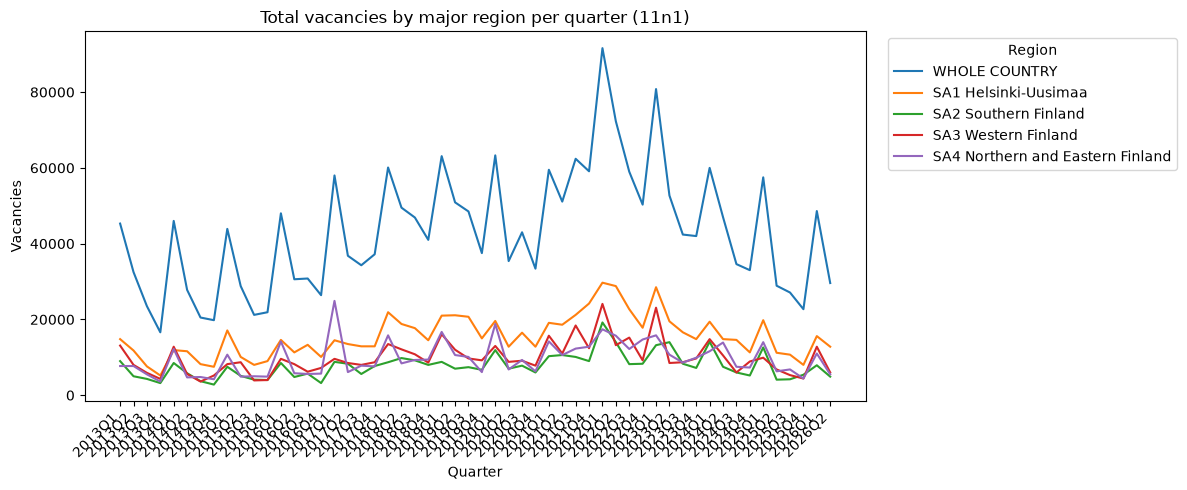

In [20]:
%matplotlib inline
df11n1 = pd.read_csv(PRO / "11n1__normalized.csv")
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    data=df11n1,
    x="timeperiod_q", y="value", hue="alue_16_20180101_text", ax=ax,
)
ax.set_title("Total vacancies by major region per quarter (11n1)")
ax.set_xlabel("Quarter")
ax.set_ylabel("Vacancies")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIG / "02_regional_total_vacancies_over_time.png", dpi=150, bbox_inches="tight")
plt.show()



## 5. Re-run data-quality summary

We confirm that normalization worked as intended by re-running the six
per-table quality checks against the completed normalized CSV files. The
lightweight diagnostic visualizations are in Section 4, while the detailed
EDA and series-selection work are performed in notebook 03.


In [21]:
# Run normalized-output quality checks now that the final CSVs exist.
per_table_obs = {}
for key in INGEST_LIST:
    tid = TABLES_CFG[key]["path"].split("/")[-1].replace(".px", "")
    per_table_obs[tid] = normalized_category_observations(tid)

for tid, obs in per_table_obs.items():
    print(f"\n{tid}")
    for cat, observation in obs:
        print(f"  {cat:35s}  {observation}")



11l1
  missing_values                       0 missing numeric values out of 270 normalized rows
  inconsistent_categories              0 missing labels across 1 normalized label columns
  duplicate_observations               0 duplicate normalized series-period keys
  incorrect_unexpected_dtypes          all expected dtypes match
  potential_outliers                   2 normalized values above p99.5=77,867 (REPORT ONLY - no action)
  irrelevant_redundant_variables       none declared

11n1
  missing_values                       0 missing numeric values out of 270 normalized rows
  inconsistent_categories              0 missing labels across 2 normalized label columns
  duplicate_observations               0 duplicate normalized series-period keys
  incorrect_unexpected_dtypes          all expected dtypes match
  potential_outliers                   2 normalized values above p99.5=77,867 (REPORT ONLY - no action)
  irrelevant_redundant_variables       none declared

12tu
  missing_valu

### Generate per-table quality reports

Compute and write `data/processed/<table_id>__quality.json` for each table.
The report includes the base §5.3 checks (nulls, negatives, duplicates, time
coverage) plus the 6-category observations from Section 3. The `categories`
key holds all 6 activity categories as a self-contained sub-object,
satisfying the plan's requirement that each quality JSON is self-contained.

In [22]:
# Per-table quality report (base §5.3 + 6-category extension).
def base_quality(tid, info):
    rows = info["rows"]
    rep = {"table_id": tid, "n_rows": len(rows)}
    sample = rows[0] if rows else {}
    dim_cols = [k for k in sample if not k.endswith("_text") and k not in ("table_id","value","value_str","source","updated","agg_source_months")]
    rep["dimensions"] = dim_cols
    rep["n_null_values"] = sum(1 for r in rows if r["value"] is None)
    rep["n_str_values"] = sum(1 for r in rows if r["value_str"] is not None)
    rep["negative_values"] = sum(1 for r in rows if isinstance(r["value"], (int,float)) and r["value"] < 0)
    time_col = info["time_col"]
    key_cols = dim_cols
    seen = set()
    dupes = 0
    for r in rows:
        k = tuple(r.get(c) for c in key_cols)
        if k in seen:
            dupes += 1
        seen.add(k)
    rep["n_duplicate_key_combos"] = dupes
    rep["n_unique_key_combos"] = len(seen)
    times = sorted({r.get(time_col) for r in rows if r.get(time_col)})
    rep["time_first"] = times[0] if times else None
    rep["time_last"]  = times[-1] if times else None
    rep["n_time_periods"] = len(times)
    rep["source"] = (sample.get("source") if sample else None)
    rep["updated"] = (sample.get("updated") if sample else None)
    return rep

quality = {}
for tid, info in all_normalized.items():
    rep = base_quality(tid, info)
    rep["categories"] = {cat: obs for cat, obs in per_table_obs.get(tid, [])}
    quality[tid] = rep
    qpath = PRO / f"{tid}__quality.json"
    qpath.write_text(json.dumps(rep, indent=2, ensure_ascii=False))
    print(f"  {tid:8s}  nulls={rep['n_null_values']:>7,d}  neg={rep['negative_values']:>5,d}  dupes={rep['n_duplicate_key_combos']:>5,d}  periods={rep['n_time_periods']:>4d}  {rep['time_first']}..{rep['time_last']}")


  11l1      nulls=      0  neg=    0  dupes=    0  periods=  54  2013Q1..2026Q2
  11n1      nulls=      0  neg=    0  dupes=    0  periods=  54  2013Q1..2026Q2
  12tu      nulls=101,912  neg=    0  dupes=    0  periods=  54  2013Q1..2026Q2
  12tw      nulls= 30,862  neg=    0  dupes=    0  periods=  70  2009Q1..2026Q2
  12r5      nulls=  6,664  neg=    0  dupes=    0  periods=  70  2009Q1..2026Q2


## 6. Build the forecast-unit catalog

The activity's "Feature Engineering" step. The forecast unit catalog is
the supervised-learning equivalent of `family_size = sibsp + parch`:
each catalog entry defines a series identity and time column for the
next-stage supervised dataset builder in `05_…`.


In [23]:
fc = {}
for tid, info in all_normalized.items():
    sample = info["rows"][0] if info["rows"] else {}
    dim_cols = [k for k in sample if not k.endswith("_text") and k not in ("table_id","value","value_str","source","updated","agg_source_months")]
    time_col = info["time_col"]
    series_cols = [c for c in dim_cols if c != time_col and c not in ("timeperiod_m",)]
    fc[tid] = {
        "table_key": info["key"],
        "title": TABLES_CFG[info["key"]]["title"],
        "series_id_columns": series_cols,
        "time_column": time_col,
        "n_series": len({tuple(r.get(c) for c in series_cols) for r in info["rows"]}),
        "n_rows": len(info["rows"]),
    }
fc_path = MAN / "forecast_unit_catalog.json"
fc_path.write_text(json.dumps(fc, indent=2, ensure_ascii=False))
for tid, v in fc.items():
    print(f"  {tid:8s}  series_cols={v['series_id_columns']}  n_series={v['n_series']:>6,d}  n_rows={v['n_rows']:>7,d}")
print(f"forecast unit catalog: {fc_path}")


  11l1      series_cols=['contentscode']  n_series=     5  n_rows=    270
  11n1      series_cols=['alue_16_20180101', 'contentscode']  n_series=     5  n_rows=    270
  12tu      series_cols=['Alue', 'Ammattiryhmä', 'Työmarkkina-asema', 'contentscode']  n_series= 8,246  n_rows=445,284
  12tw      series_cols=['Alue', 'Toimiala', 'Työnantajan sektori', 'Työpaikan työn kesto', 'contentscode']  n_series= 2,147  n_rows=150,290
  12r5      series_cols=['Alue', 'contentscode']  n_series=   842  n_rows= 58,940
forecast unit catalog: /Users/Alan/Documents/Study/MLProject-JobAI/data/manifests/forecast_unit_catalog.json


### Cross-table coverage report

For every series, this report compares its observed quarterly coverage with
the full expected range for its table. It records missing quarters, missing
numeric values, and a clear `PASS` or `REVIEW` status with an issue reason.
The detailed results are written to
`data/processed/cross_table_coverage.csv`, and a short pass/review summary is
printed below the code cell.

In [24]:
# Cross-table coverage report with reader-friendly status fields.
cov_rows = []
for tid, info in all_normalized.items():
    rows = info["rows"]
    time_col = info["time_col"]
    sample = rows[0] if rows else {}
    dim_cols = [k for k in sample if not k.endswith("_text") and k not in ("table_id","value","value_str","source","updated","agg_source_months")]
    table_times = sorted({r.get(time_col) for r in rows if r.get(time_col)})
    expected_first = table_times[0]
    expected_last = table_times[-1]
    expected_periods = quarter_ordinal(expected_last) - quarter_ordinal(expected_first) + 1
    by_key = defaultdict(lambda: {"times": set(), "missing_values": 0})
    for r in rows:
        if r.get(time_col) is None:
            continue
        key = tuple((c, r.get(c)) for c in dim_cols if c != time_col)
        by_key[key]["times"].add(r[time_col])
        if r.get("value") is None:
            by_key[key]["missing_values"] += 1
    for k, coverage in by_key.items():
        times = coverage["times"]
        sorted_times = sorted(times)
        missing_quarters = expected_periods - len(times)
        missing_values = coverage["missing_values"]
        issues = []
        if missing_quarters:
            issues.append(f"{missing_quarters} missing quarter(s)")
        if missing_values:
            issues.append(f"{missing_values} missing value(s)")
        if sorted_times[0] != expected_first or sorted_times[-1] != expected_last:
            issues.append("shorter time range than table")
        cov_rows.append({
            "table_id": tid,
            "dimension_signature": "|".join(f"{c}={v}" for c, v in k),
            "expected_periods": expected_periods,
            "n_time_periods": len(times),
            "missing_quarters": missing_quarters,
            "missing_values": missing_values,
            "time_first": sorted_times[0],
            "time_last": sorted_times[-1],
            "coverage_status": "REVIEW" if issues else "PASS",
            "issue_reason": "; ".join(issues) if issues else "complete quarterly coverage and values",
        })
cov_path = PRO / "cross_table_coverage.csv"
coverage_fields = ["table_id","dimension_signature","expected_periods","n_time_periods","missing_quarters","missing_values","time_first","time_last","coverage_status","issue_reason"]
with open(cov_path, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=coverage_fields)
    w.writeheader()
    w.writerows(cov_rows)
n_pass = sum(r["coverage_status"] == "PASS" for r in cov_rows)
n_review = len(cov_rows) - n_pass
print(f"cross-table coverage: {len(cov_rows):,} series — PASS={n_pass:,}, REVIEW={n_review:,} -> {cov_path.name}")


cross-table coverage: 11,245 series — PASS=2,293, REVIEW=8,952 -> cross_table_coverage.csv


## 7. Final summary and before-vs-after comparison

The activity's Section 7.3 "Before vs After" table, applied to the PxWeb
data. The "before" state is the raw fetch (Section 3); the "after" state is
the normalized output (Section 4 + 5).


In [25]:
total_rows = sum(v["n_rows"] for v in fc.values())
total_series = sum(v["n_series"] for v in fc.values())
print("FINAL DATASET SIZE")
print(f"  tables         : {len(fc)}")
print(f"  total rows     : {total_rows:>10,d}")
print(f"  total series   : {total_series:>10,d}")


FINAL DATASET SIZE
  tables         : 5
  total rows     :    655,054
  total series   :     11,245


### Before-vs-after comparison

Build a comparison table mirroring the activity's Section 5.3 template. For
each table, we show raw cells vs. normalized rows, unique series counts, time
coverage, and null counts before vs. after cleaning. This makes it visible
that no data was dropped (nulls stay null; outliers are only reported) while
the cleaning transformation (monthly→quarterly) is applied.

In [26]:
import re
import json as _json
try:
    from IPython.display import display as _display
except ImportError:
    def __display(x):
        if hasattr(x, 'to_string'):
            print(x.to_string())
        else:
            print(x)

rows = []
for tid, info in all_normalized.items():
    q = _json.loads(open(PRO / f"{tid}__quality.json").read())
    raw_slices = list((RAW).glob(f"{tid}__data__slice_*.json"))
    raw_cells = 0
    for p in raw_slices:
        st = _json.loads(p.read_text())
        n = 1
        for s in st["size"]:
            n *= s
        raw_cells += n
    mv = q["categories"]["missing_values"]
    m = re.search(r"([\d,]+)\s+null", mv)
    raw_nulls = int(m.group(1).replace(",", "")) if m else 0
    rows.append({
        "table_id": tid,
        "raw_cells": raw_cells,
        "normalized_rows": q["n_rows"],
        "n_unique_series": fc[tid]["n_series"],
        "n_time_periods": q["n_time_periods"],
        "time_first": q["time_first"],
        "time_last": q["time_last"],
        "raw_nulls": raw_nulls,
        "normalized_nulls": q["n_null_values"],
        "duplicates": q["n_duplicate_key_combos"],
    })
before_after = pd.DataFrame(rows)
_display(before_after)



,table_id,raw_cells,normalized_rows,n_unique_series,n_time_periods,time_first,time_last,raw_nulls,normalized_nulls,duplicates
0,11l1,270,270,5,54,2013Q1,2026Q2,0,0,0
1,11n1,270,270,5,54,2013Q1,2026Q2,0,0,0
2,12tu,445284,445284,8246,54,2013Q1,2026Q2,0,101912,0
3,12tw,453017,150290,2147,70,2009Q1,2026Q2,0,30862,0
4,12r5,58940,58940,842,70,2009Q1,2026Q2,0,6664,0


In [27]:
# Markdown-style "Before vs After" table mirroring the activity template.
print("| Table | Raw cells | Normalized rows | Series | Periods | Range |")
print("|-------|----------:|----------------:|-------:|--------:|-------|")
for r in rows:
    print(f"| {r['table_id']} | {r['raw_cells']:,} | {r['normalized_rows']:,} | {r['n_unique_series']:,} | {r['n_time_periods']} | {r['time_first']} .. {r['time_last']} |")

print()
print("Cleaning actions applied:")
print("  - KEHA monthly -> quarterly (end-of-quarter rule)")
print("  - dtypes validated against configs/data_quality.yaml (tolerated pandas read_csv promotion)")
print("  - outlier counts reported, NO removal/capping (see outlier_policy.md)")
print()
print("Outputs:")
for f in sorted(PRO.glob("*")):
    if f.is_file():
        print(f"  {f.relative_to(REPO)}")
print()
print("Aggregate outputs:")
for f in sorted(MAN.glob("*")):
    if f.is_file():
        print(f"  {f.relative_to(REPO)}")


| Table | Raw cells | Normalized rows | Series | Periods | Range |
|-------|----------:|----------------:|-------:|--------:|-------|
| 11l1 | 270 | 270 | 5 | 54 | 2013Q1 .. 2026Q2 |
| 11n1 | 270 | 270 | 5 | 54 | 2013Q1 .. 2026Q2 |
| 12tu | 445,284 | 445,284 | 8,246 | 54 | 2013Q1 .. 2026Q2 |
| 12tw | 453,017 | 150,290 | 2,147 | 70 | 2009Q1 .. 2026Q2 |
| 12r5 | 58,940 | 58,940 | 842 | 70 | 2009Q1 .. 2026Q2 |

Cleaning actions applied:
  - KEHA monthly -> quarterly (end-of-quarter rule)
  - dtypes validated against configs/data_quality.yaml (tolerated pandas read_csv promotion)
  - outlier counts reported, NO removal/capping (see outlier_policy.md)

Outputs:
  data/processed/11l1__normalized.csv
  data/processed/11l1__quality.json
  data/processed/11n1__normalized.csv
  data/processed/11n1__quality.json
  data/processed/12r5__normalized.csv
  data/processed/12r5__quality.json
  data/processed/12tu__normalized.csv
  data/processed/12tu__quality.json
  data/processed/12tw__normalized.csv
 